### Imports and downloading data

In [28]:
import matplotlib.pyplot as plt
from torchvision import datasets
from torchvision.transforms import ToTensor
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import torch.optim as optim
from torch.nn import CrossEntropyLoss
import wandb

train_data = datasets.FashionMNIST(root='data', train=True, download=True, transform=ToTensor())
test_data = datasets.FashionMNIST(root='data', train=False, download=True, transform=ToTensor())

img, label = train_data[3]
img.shape

torch.Size([1, 28, 28])

In [29]:
len(train_data)

60000

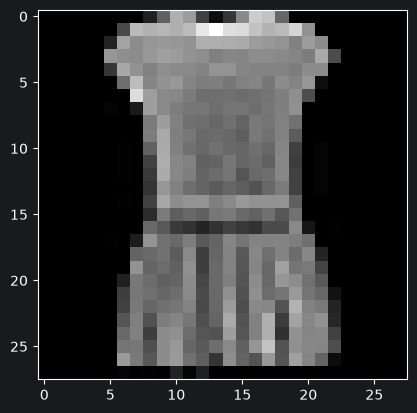

In [30]:
plt.imshow(img.squeeze(), cmap='gray')

### Dataloaders

In [31]:
train_dataloader = DataLoader(train_data, batch_size=64, shuffle=True)
test_dataloader = DataLoader(test_data, batch_size=64, shuffle=False)

### Convolutional Neural Network

In [32]:
class Model(nn.Module):
    def __init__(self):
        super().__init__()
        self.cnn = nn.Sequential(
            nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Flatten(),
            nn.Linear(in_features=64*7*7, out_features=128),
            nn.ReLU(),
            nn.Linear(in_features=128, out_features=10),
        )

    def forward(self, x):
        logits = self.cnn(x)
        return logits

### Training and evaluation

In [33]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def train_model(lr):
    wandb.init(
        project='fashion_mnist',
        name=f"cnn-lr: {lr}",
        config={'lr': lr, 'epochs': 20, 'batch_size': 64}
    )

    model = Model().to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    for epoch in range(20):
        running_loss = 0.0
        model.train()
        for X, y in train_dataloader:
            X, y = X.to(device), y.to(device)
            optimizer.zero_grad()
            logits = model(X)
            loss = criterion(logits, y)
            running_loss += loss.item()
            loss.backward()
            optimizer.step()

        avg_loss = running_loss / len(train_dataloader)

        model.eval()
        correct = 0
        total = 0
        with torch.no_grad():
            for X, y in test_dataloader:
                X, y = X.to(device), y.to(device)
                logits = model(X)
                predictions = logits.argmax(dim=1)
                correct += (predictions == y).sum().item()
                total += len(y)
        accuracy = correct / total

        wandb.log({'accuracy': accuracy, 'avg_loss': avg_loss, 'epoch': epoch})
    wandb.finish()

for lr in [0.001, 0.01, 0.1]:
    train_model(lr)

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from C:\Users\kubak\_netrc.
wandb: Currently logged in as: jacob_21 (jacob_21-agh-univeristy-of-krakow) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: setting up run id3ygooy
wandb: Tracking run with wandb version 0.28.2
wandb: Run data is saved locally in C:\Users\kubak\Documents\Programming\PycharmProjects\MachineLearning\FashionMNIST-CNN\wandb\run-20260902_174700-id3ygooy
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run cnn-lr: 0.001
wandb:  View project at https://wandb.ai/jacob_21-agh-univeristy-of-krakow/fashion_mnist
wandb:  View run at https://wandb.ai/jacob_21-agh-univeristy-of-krakow/fashion_mnist/runs/id3ygooy
wandb: updating run metadata
wandb: uploading wandb-summary.json; uploading config.yaml
wandb: uploading history steps 19-19, summary
wandb: 
wandb: Run history:
wandb: accuracy ▁▄▅▆▇▇██▇██▇▇▇▇█▇█▇█
wandb: avg_loss █▅▅▄▄▃▃▃▃▂▂▂▂▁▁▁▁▁▁▁
wandb:    epoch ▁▁▂▂